# MEG HHSA Examples: Ensemble Sift, Masked Sift, CEEMDAN, and ICEEMDAN

This notebook shows a practical single-channel MEG workflow using the HHSA package in this repository. Each decomposition method is followed by diagnostic plots so you can check whether the pipeline is behaving sensibly at each stage.

The notebook tries to use a locally cached MNE sample MEG recording. If the sample data are not available, it falls back to a synthetic MEG-like signal with theta, alpha, beta, burst, drift, and sensor-noise components. The fallback keeps the examples runnable without downloads.

For a first run, keep `seconds`, `ensemble_size`, and `max_imfs` small. Increase them after the plots look reasonable.


In [ ]:
!pip uninstall PyEMD EMD-signal -y

In [ ]:
import sys
!{sys.executable} -m pip install EMD-signal

In [1]:
from PyEMD import EMD, CEEMDAN
import numpy as np

# Quick sanity check
print("PyEMD successfully loaded!")

PyEMD successfully loaded!


In [2]:
# If you run this notebook from the examples folder, make the repository package importable.
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "examples":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings


import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as scipy_signal
from scipy.signal import detrend, welch
from PyEMD import EMD

from hhsa import mode_energy, run_hhsa

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})


## 1. Load or Simulate a MEG Channel

`load_meg_or_synthetic` returns one preprocessed channel, its sampling rate, and a source label. For real MNE data it picks a magnetometer, crops a short segment, resamples it, filters it, converts to femtotesla, detrends, and z-scores. For synthetic data it creates a signal with known oscillatory structure so the decomposition diagnostics are easy to interpret.


In [3]:
def zscore(x):
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / (np.std(x) + np.finfo(float).eps)


def make_synthetic_meg(seconds=6.0, sfreq=250.0, random_state=13):
    rng = np.random.default_rng(random_state)
    t = np.arange(int(seconds * sfreq)) / sfreq

    theta = 0.40 * np.sin(2 * np.pi * 5.5 * t + 0.2)
    alpha_envelope = 1.0 + 0.35 * np.sin(2 * np.pi * 1.1 * t)
    alpha = alpha_envelope * np.sin(2 * np.pi * 10.0 * t)

    burst_center = seconds * 0.55
    burst_width = 0.35
    beta_envelope = np.exp(-0.5 * ((t - burst_center) / burst_width) ** 2)
    beta_burst = 0.65 * beta_envelope * np.sin(2 * np.pi * 22.0 * t + 0.5)

    line_like = 0.08 * np.sin(2 * np.pi * 50.0 * t)
    drift = 0.25 * np.sin(2 * np.pi * 0.35 * t)
    noise = 0.25 * rng.normal(size=t.size)

    synthetic = theta + alpha + beta_burst + line_like + drift + noise
    return zscore(detrend(synthetic)), sfreq, "synthetic MEG-like fallback"


def load_meg_or_synthetic(seconds=6.0, target_sfreq=250.0, random_state=13):
    try:
        import mne
        from mne.datasets import sample

        data_path = Path(sample.data_path(download=False, verbose=False))
        raw_path = data_path / "MEG" / "sample" / "sample_audvis_raw.fif"
        if not raw_path.exists():
            raise FileNotFoundError(raw_path)

        raw = mne.io.read_raw_fif(raw_path, preload=True, verbose=False)
        raw.pick_types(meg="mag", eeg=False, eog=False, stim=False, exclude="bads")
        raw.crop(tmin=0.0, tmax=seconds, include_tmax=False)
        raw.resample(target_sfreq, npad="auto", verbose=False)
        raw.filter(l_freq=1.0, h_freq=80.0, fir_design="firwin", verbose=False)

        data = raw.get_data(picks=[0])[0] * 1e15  # tesla -> femtotesla for readable values
        return zscore(detrend(data)), float(raw.info["sfreq"]), f"MNE sample MEG: {raw.ch_names[0]}"
    except Exception as exc:
        x, sfreq, source = make_synthetic_meg(seconds, target_sfreq, random_state)
        return x, sfreq, f"{source}; real MEG load skipped ({type(exc).__name__})"


seconds = 6.0
signal, sample_rate, source = load_meg_or_synthetic(seconds=seconds, target_sfreq=250.0, random_state=42)
time = np.arange(signal.size) / sample_rate

print(source)
print(f"samples={signal.size}, sample_rate={sample_rate:.1f} Hz, duration={signal.size / sample_rate:.2f} s")


synthetic MEG-like fallback; real MEG load skipped (FileNotFoundError)
samples=1500, sample_rate=250.0 Hz, duration=6.00 s


## 2. Raw and Preprocessing Quality Checks

These plots answer the first sanity questions: is the channel finite, centered, scaled reasonably, and does its power spectrum contain plausible frequencies for the chosen analysis band?


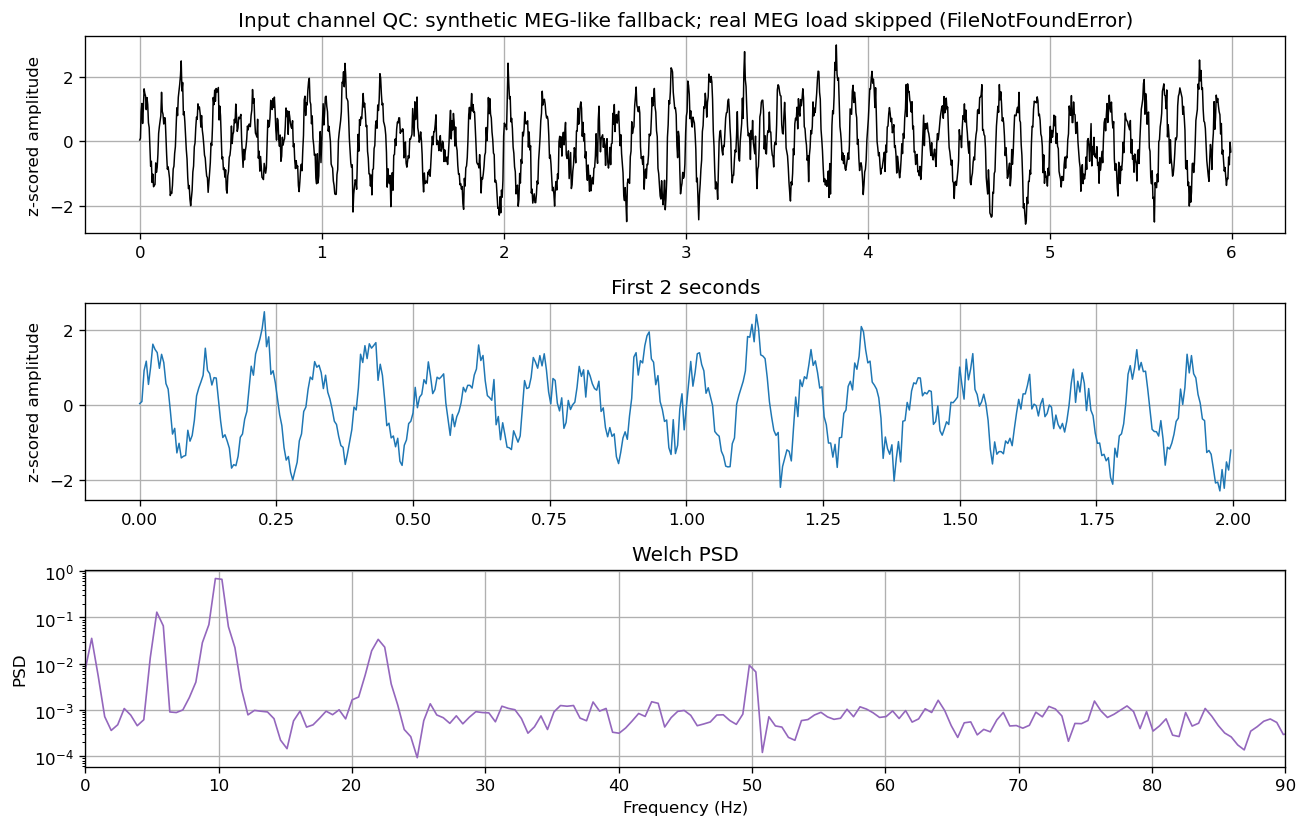

In [4]:
def plot_signal_qc(x, sfreq, title="MEG channel QC"):
    t = np.arange(x.size) / sfreq
    freqs, psd = welch(x, fs=sfreq, nperseg=min(512, x.size))

    fig, axes = plt.subplots(3, 1, figsize=(11, 7))
    axes[0].plot(t, x, color="black", linewidth=0.9)
    axes[0].set_title(title)
    axes[0].set_ylabel("z-scored amplitude")

    zoom_n = min(x.size, int(2.0 * sfreq))
    axes[1].plot(t[:zoom_n], x[:zoom_n], color="tab:blue", linewidth=0.9)
    axes[1].set_title("First 2 seconds")
    axes[1].set_ylabel("z-scored amplitude")

    axes[2].semilogy(freqs, psd, color="tab:purple", linewidth=1.0)
    axes[2].set_xlim(0, min(90, sfreq / 2))
    axes[2].set_xlabel("Frequency (Hz)")
    axes[2].set_ylabel("PSD")
    axes[2].set_title("Welch PSD")

    fig.tight_layout()
    return fig, axes


plot_signal_qc(signal, sample_rate, title=f"Input channel QC: {source}");


## 3. Shared Plotting Helpers

The same diagnostics are applied to every method:

1. first-layer IMFs plus residue,
2. reconstruction overlay and residual error,
3. instantaneous amplitude and frequency tracks,
4. second-layer decomposition of a selected amplitude envelope,
5. Hilbert-Huang and Holo-Hilbert spectra.


In [5]:
def plot_decomposition_diagnostics(result, label, max_modes=5):
    n_modes = min(result.imfs.shape[0], max_modes)
    rows = n_modes + 3
    t = np.arange(result.signal.size) / result.sample_rate

    fig, axes = plt.subplots(rows, 1, sharex=True, figsize=(11, max(6, 1.35 * rows)))
    axes[0].plot(t, result.signal, color="black", linewidth=0.9)
    axes[0].set_title(f"{label}: signal, IMFs, residue")
    axes[0].set_ylabel("signal")

    for idx in range(n_modes):
        axes[idx + 1].plot(t, result.imfs[idx], linewidth=0.9)
        axes[idx + 1].set_ylabel(f"IMF {idx + 1}")

    axes[n_modes + 1].plot(t, result.residue, color="tab:red", linewidth=0.9)
    axes[n_modes + 1].set_ylabel("residue")

    axes[-1].plot(t, result.signal, color="black", linewidth=1.0, label="signal")
    axes[-1].plot(t, result.reconstruction, color="tab:green", linewidth=0.9, alpha=0.8, label="IMFs + residue")
    axes[-1].set_ylabel("recon")
    axes[-1].set_xlabel("Time (s)")
    axes[-1].legend(loc="upper right")
    axes[-1].set_title(f"relative reconstruction error = {result.reconstruction_error:.3e}")

    fig.tight_layout()
    return fig, axes


def plot_am_fm_diagnostics(result, label, max_modes=4, max_frequency=80.0):
    n_modes = min(result.imfs.shape[0], max_modes)
    if n_modes == 0:
        print(f"{label}: no IMFs were extracted.")
        return None, None

    t = np.arange(result.signal.size) / result.sample_rate
    fig, axes = plt.subplots(n_modes, 2, sharex=True, figsize=(12, max(5, 1.9 * n_modes)))
    if n_modes == 1:
        axes = np.asarray([axes])

    for idx in range(n_modes):
        axes[idx, 0].plot(t, result.amplitude[idx], color="tab:blue", linewidth=0.9)
        axes[idx, 0].set_ylabel(f"IMF {idx + 1}")
        axes[idx, 0].set_title("Instantaneous amplitude" if idx == 0 else "")

        freq = np.clip(result.frequency[idx], 0, max_frequency)
        axes[idx, 1].plot(t, freq, color="tab:orange", linewidth=0.9)
        axes[idx, 1].set_ylim(0, max_frequency)
        axes[idx, 1].set_title("Instantaneous frequency" if idx == 0 else "")

    axes[-1, 0].set_xlabel("Time (s)")
    axes[-1, 1].set_xlabel("Time (s)")
    fig.suptitle(f"{label}: AM/FM checks", y=1.01)
    fig.tight_layout()
    return fig, axes


def strongest_imf_index(result):
    if result.imfs.size == 0:
        return None
    return int(np.argmax(mode_energy(result.imfs)))


def plot_second_layer_diagnostics(result, label, carrier_index=None, max_am_modes=4, max_frequency=40.0):
    if carrier_index is None:
        carrier_index = strongest_imf_index(result)
    if carrier_index is None or carrier_index >= len(result.am_imfs):
        print(f"{label}: no second-layer AM decomposition is available.")
        return None, None

    am_modes = result.am_imfs[carrier_index]
    am_residue = result.am_residues[carrier_index]
    envelope = result.amplitude[carrier_index]
    n_modes = min(am_modes.shape[0], max_am_modes)
    t = np.arange(result.signal.size) / result.sample_rate

    fig, axes = plt.subplots(n_modes + 2, 1, sharex=True, figsize=(11, max(5, 1.4 * (n_modes + 2))))
    axes[0].plot(t, envelope, color="tab:blue", linewidth=0.9)
    axes[0].set_title(f"{label}: second-layer AM decomposition from carrier IMF {carrier_index + 1}")
    axes[0].set_ylabel("envelope")

    for idx in range(n_modes):
        axes[idx + 1].plot(t, am_modes[idx], linewidth=0.9)
        axes[idx + 1].set_ylabel(f"AM IMF {idx + 1}")

    axes[-1].plot(t, am_residue, color="tab:red", linewidth=0.9)
    axes[-1].set_ylabel("AM residue")
    axes[-1].set_xlabel("Time (s)")
    fig.tight_layout()

    if result.am_frequency[carrier_index].size:
        n_freq_modes = min(result.am_frequency[carrier_index].shape[0], max_am_modes)
        fig2, ax2 = plt.subplots(figsize=(11, 3.2))
        for idx in range(n_freq_modes):
            ax2.plot(t, np.clip(result.am_frequency[carrier_index][idx], 0, max_frequency), linewidth=0.9, label=f"AM IMF {idx + 1}")
        ax2.set_ylim(0, max_frequency)
        ax2.set_xlabel("Time (s)")
        ax2.set_ylabel("AM frequency (Hz)")
        ax2.set_title(f"{label}: second-layer instantaneous AM frequency")
        ax2.legend(loc="upper right", ncol=2)
        fig2.tight_layout()

    return fig, axes


def plot_spectral_diagnostics(result, label):
    t = np.arange(result.signal.size) / result.sample_rate
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(result.carrier_bins, result.marginal, color="black", linewidth=1.0)
    axes[0].set_xscale("log")
    axes[0].set_xlabel("Carrier frequency (Hz)")
    axes[0].set_ylabel("Power")
    axes[0].set_title("Marginal HHT")

    hht = np.asarray(result.hht)
    im0 = axes[1].imshow(
        hht,
        aspect="auto",
        origin="lower",
        extent=[t[0], t[-1], result.carrier_bins[0], result.carrier_bins[-1]],
        cmap="magma",
    )
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Carrier frequency (Hz)")
    axes[1].set_title("Hilbert-Huang spectrum")
    fig.colorbar(im0, ax=axes[1], fraction=0.046, pad=0.04)

    holo = np.asarray(result.holospectrum)
    im1 = axes[2].imshow(
        holo,
        aspect="auto",
        origin="lower",
        extent=[result.am_bins[0], result.am_bins[-1], result.carrier_bins[0], result.carrier_bins[-1]],
        cmap="viridis",
    )
    axes[2].set_xscale("log")
    axes[2].set_yscale("log")
    axes[2].set_xlabel("AM frequency (Hz)")
    axes[2].set_ylabel("Carrier frequency (Hz)")
    axes[2].set_title("Time-averaged holospectrum")
    fig.colorbar(im1, ax=axes[2], fraction=0.046, pad=0.04)

    fig.suptitle(label, y=1.03)
    fig.tight_layout()
    return fig, axes


## 4. Configure the Four Decomposition Methods

`run_hhsa` runs the full two-layer HHSA workflow. The `decomposition` argument controls both the first-layer carrier decomposition and the second-layer amplitude-envelope decomposition.

For `mask_sift`, EMD-Python expects mask frequencies in cycles per sample, so the examples divide Hz by `sample_rate`. Adjust these masks to the frequency bands you expect in your MEG recording.


In [6]:
COMMON_KWARGS = dict(
    frequency_method="hybrid",
    max_imfs=4,
    max_am_imfs=2,
    ensemble_size=8,
    noise_width=0.12,
    random_state=42,
    max_siftings=20,
    stop_sd=0.2,
    carrier_hist=(1.0, 90.0, 96, "log"),
    am_hist=(0.5, 40.0, 64, "log"),
    emd_backend="auto",
    sift_acceleration="none",
)

METHOD_KWARGS = {
    "Ensemble sift": dict(decomposition="ensemble_sift"),
    "Masked sift": dict(
        decomposition="mask_sift",
        mask_freqs=np.array([45.0, 25.0, 12.0, 6.0]) / sample_rate,
        mask_amp=1.0,
        mask_amp_mode="ratio_sig",
    ),
    "CEEMDAN": dict(decomposition="ceemdan"),
    "ICEEMDAN": dict(decomposition="iceemdan"),
}

print("Demo settings:")
for key, value in COMMON_KWARGS.items():
    print(f"  {key}: {value}")


Demo settings:
  frequency_method: hybrid
  max_imfs: 4
  max_am_imfs: 2
  ensemble_size: 8
  noise_width: 0.12
  random_state: 42
  max_siftings: 20
  stop_sd: 0.2
  carrier_hist: (1.0, 90.0, 96, 'log')
  am_hist: (0.5, 40.0, 64, 'log')
  emd_backend: auto
  sift_acceleration: none


## 5. Run HHSA with Each Method

This cell catches method-specific dependency errors. `ensemble_sift` and `mask_sift` need EMD-Python (`emd`); `ceemdan` needs PyEMD (`EMD-signal`, imported as `PyEMD`); `iceemdan` uses the local implementation plus one of the EMD backends for internal sifts.


In [7]:
results = {}
failures = {}

for label, method_kwargs in METHOD_KWARGS.items():
    kwargs = {**COMMON_KWARGS, **method_kwargs}
    print(f"Running {label} ...")
    try:
        results[label] = run_hhsa(signal, sample_rate, **kwargs)
        result = results[label]
        print(
            f"  extracted {result.imfs.shape[0]} IMFs; "
            f"reconstruction error={result.reconstruction_error:.3e}; "
            f"HHT={result.hht.shape}; holo={result.holospectrum.shape}"
        )
    except Exception as exc:
        failures[label] = exc
        print(f"  skipped {label}: {type(exc).__name__}: {exc}")

print(f"Finished {len(results)} method(s), skipped {len(failures)} method(s).")


Running Ensemble sift ...
  extracted 4 IMFs; reconstruction error=5.761e-18; HHT=(96, 1500); holo=(96, 64)
Running Masked sift ...
  extracted 4 IMFs; reconstruction error=4.623e-18; HHT=(96, 1500); holo=(96, 64)
Running CEEMDAN ...
  extracted 4 IMFs; reconstruction error=7.315e-18; HHT=(96, 1500); holo=(96, 64)
Running ICEEMDAN ...
  extracted 4 IMFs; reconstruction error=1.130e-16; HHT=(96, 1500); holo=(96, 64)
Finished 4 method(s), skipped 0 method(s).


## 6. First-Layer Decomposition Checks

Use these plots to inspect mode ordering, mode mixing, endpoint artifacts, slow residue drift, and reconstruction. A low reconstruction error confirms that the extracted IMFs plus residue preserve the input signal.


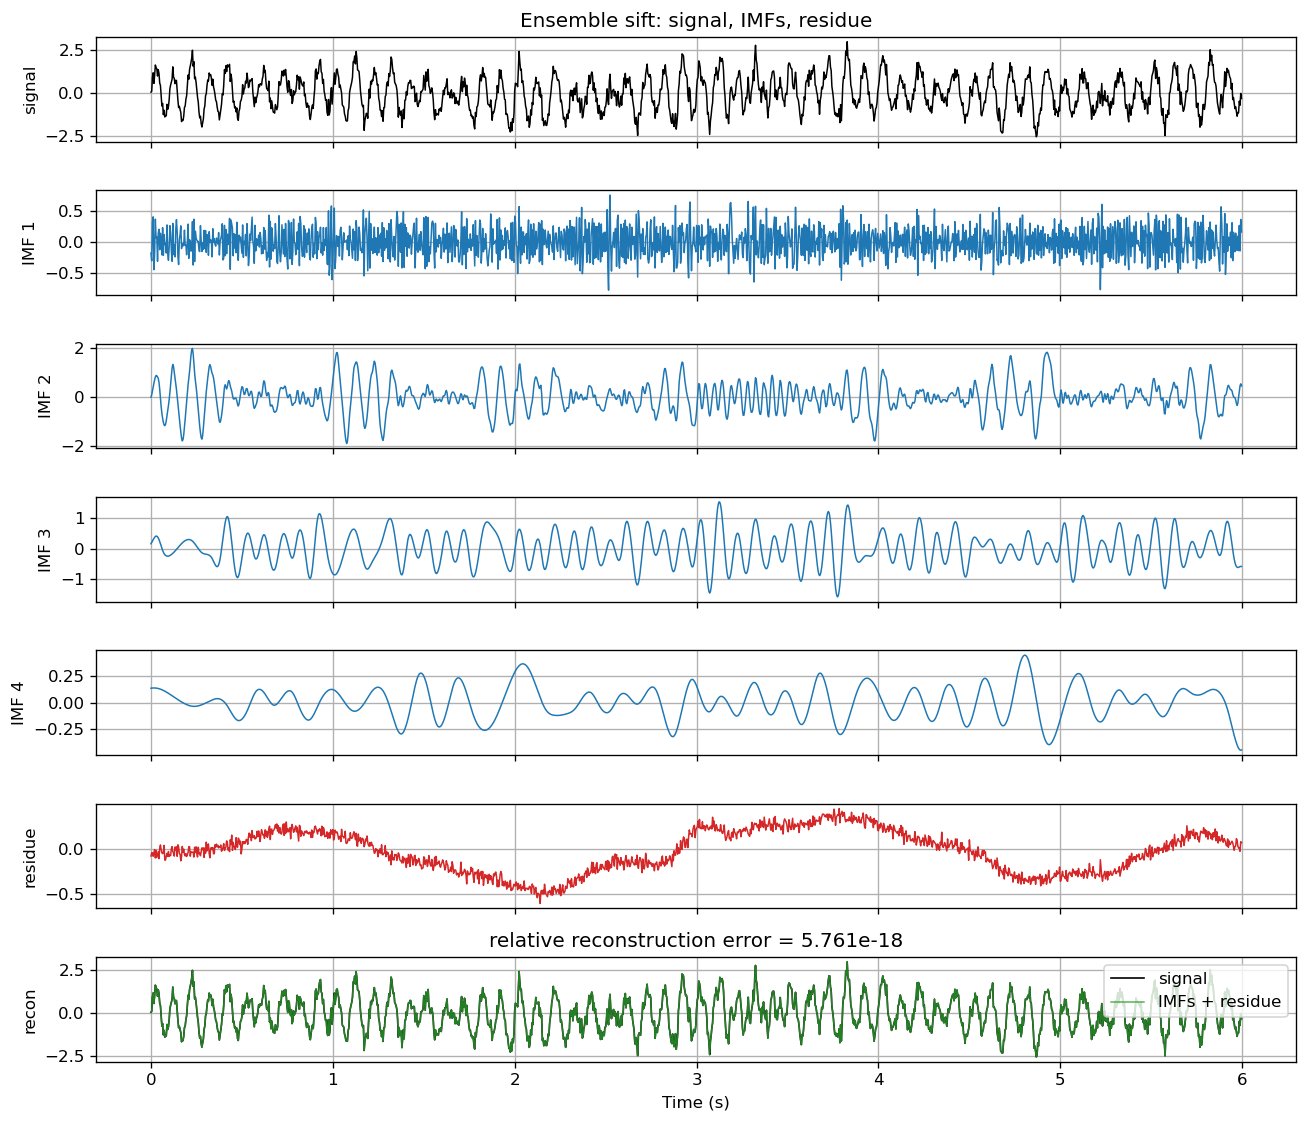

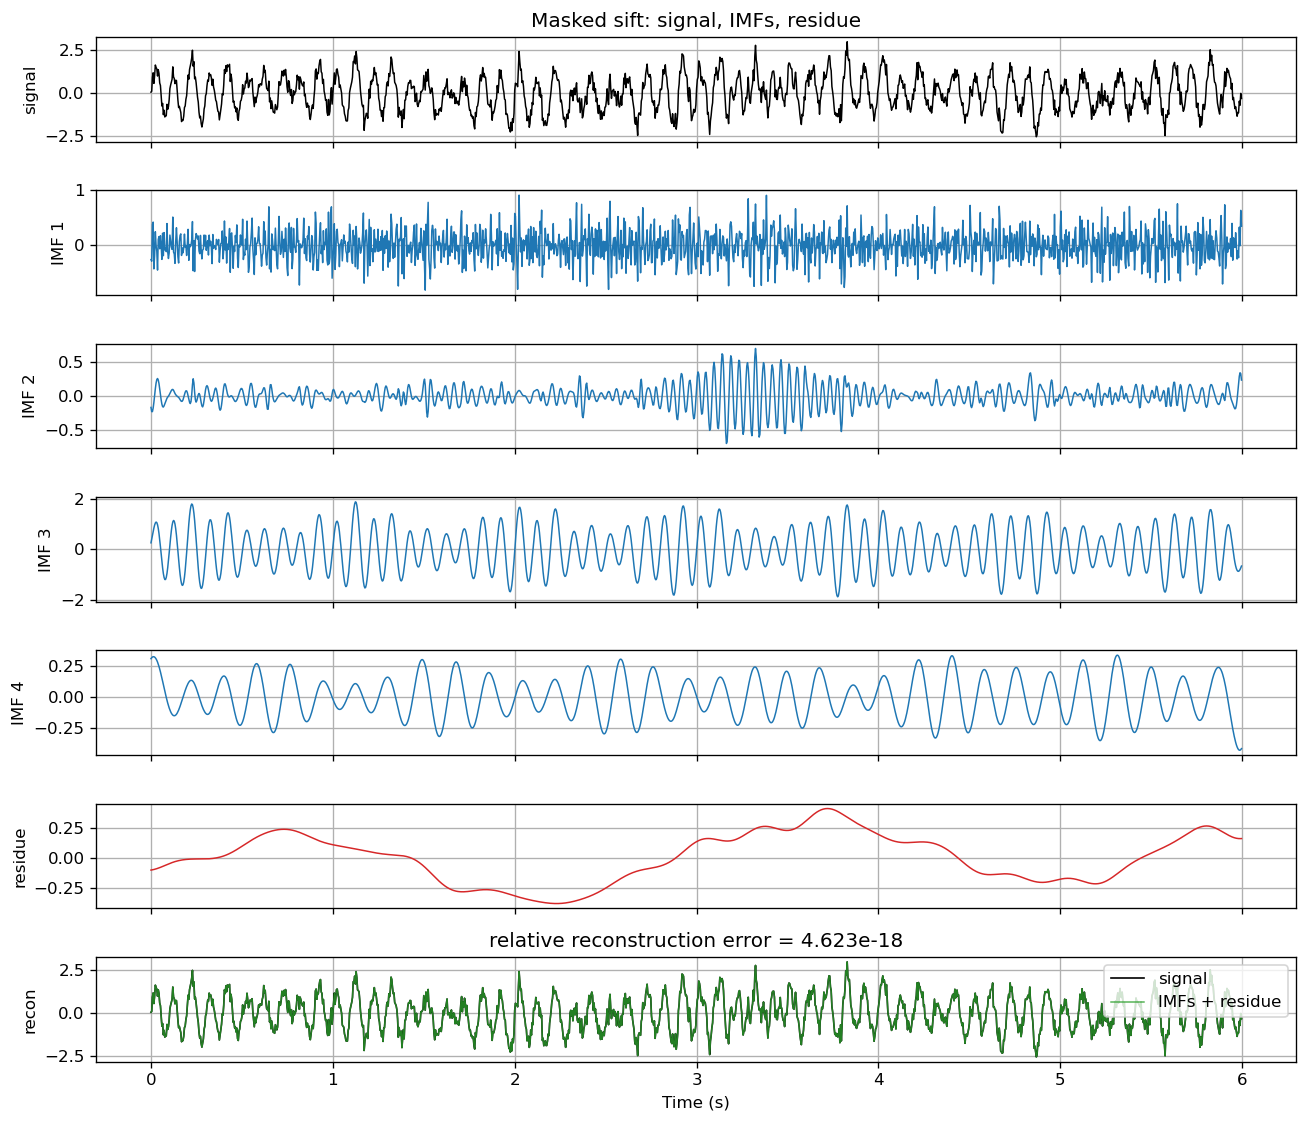

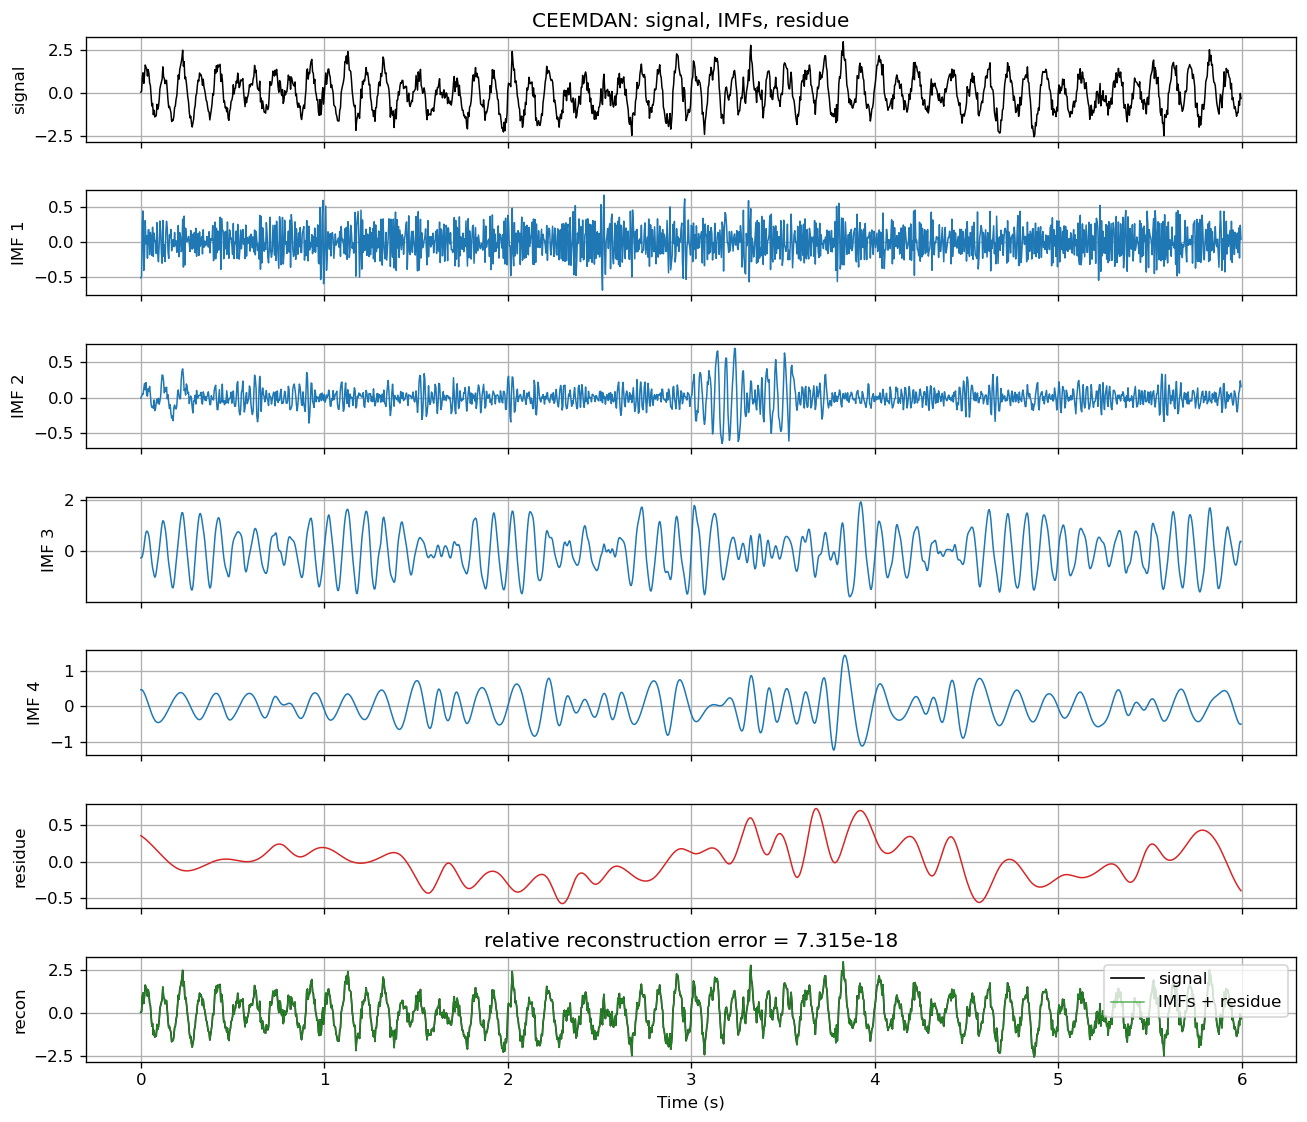

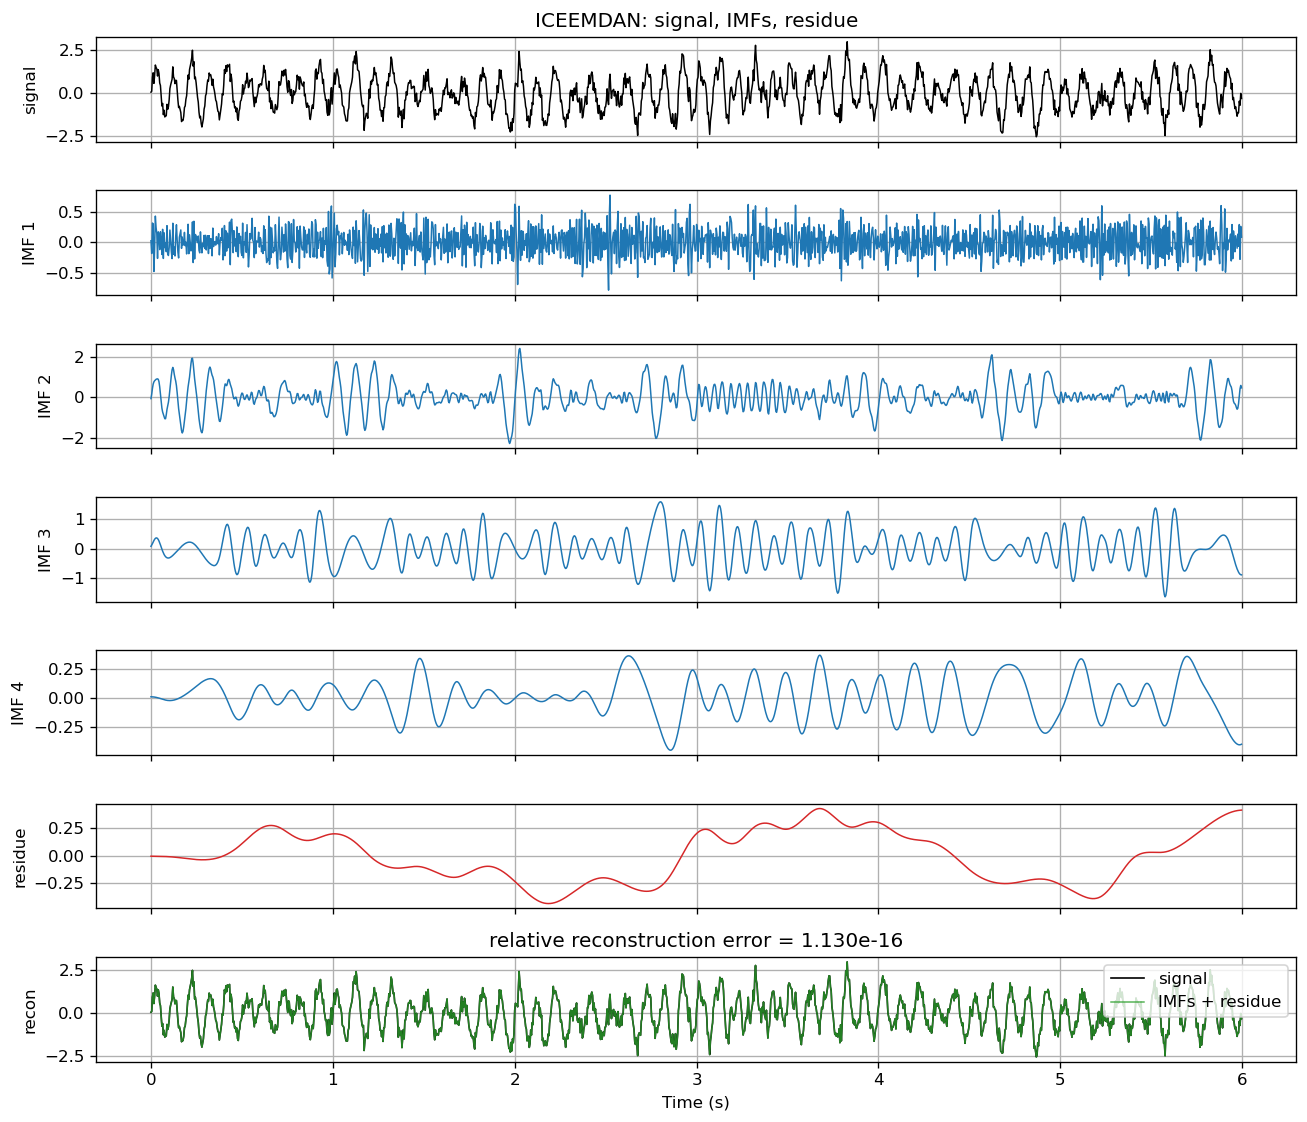

In [8]:
for label, result in results.items():
    plot_decomposition_diagnostics(result, label, max_modes=COMMON_KWARGS["max_imfs"]);


## 7. Instantaneous Amplitude and Frequency Checks

The amplitude tracks should be non-negative and slowly varying relative to their carrier IMFs. The instantaneous-frequency tracks should mostly sit in plausible MEG bands rather than being dominated by spikes or negative values.


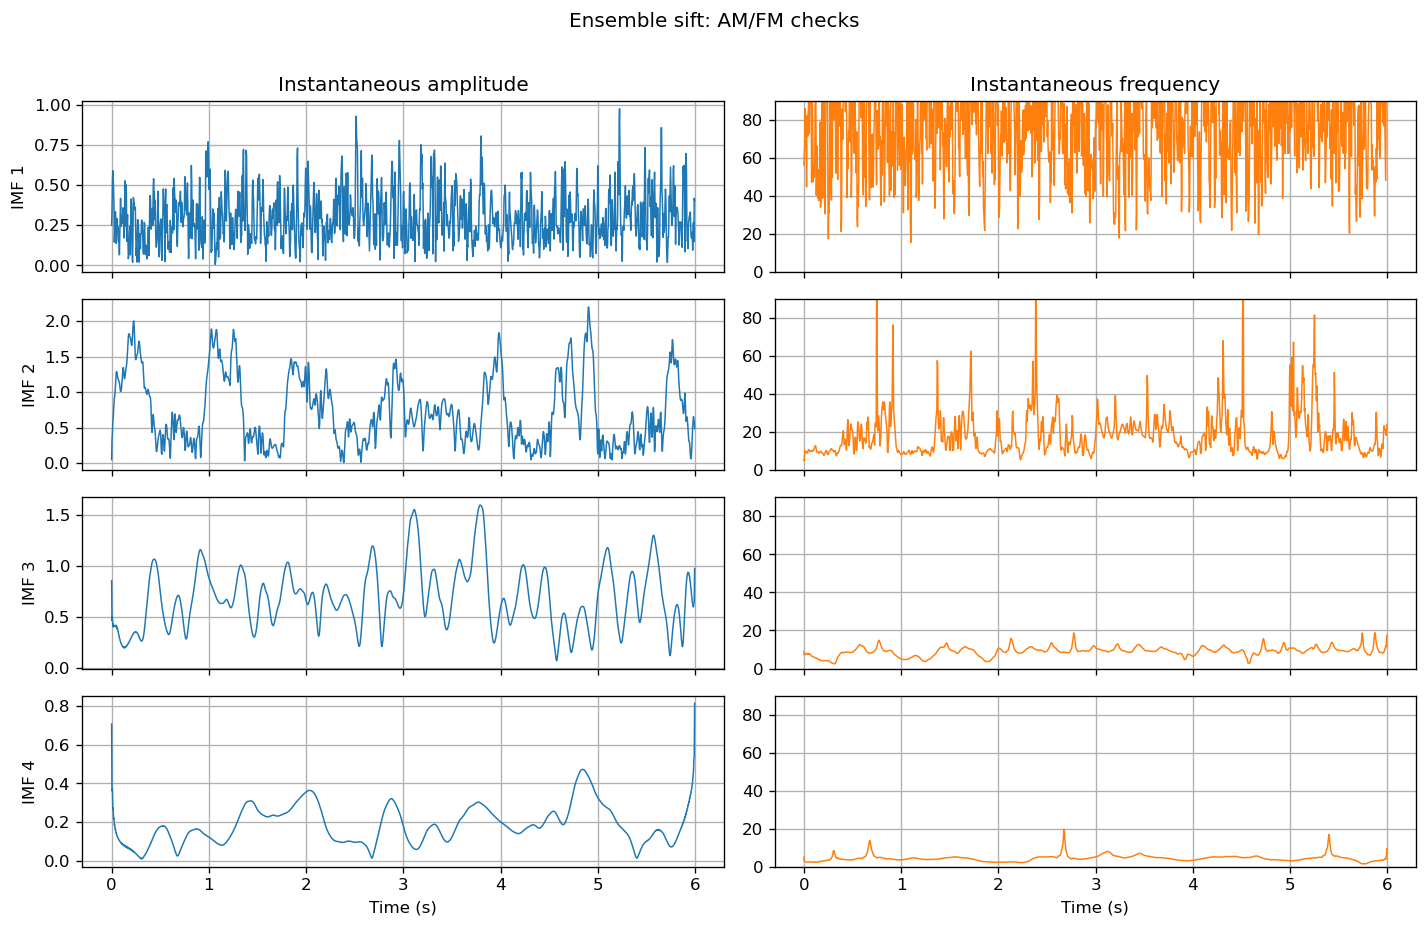

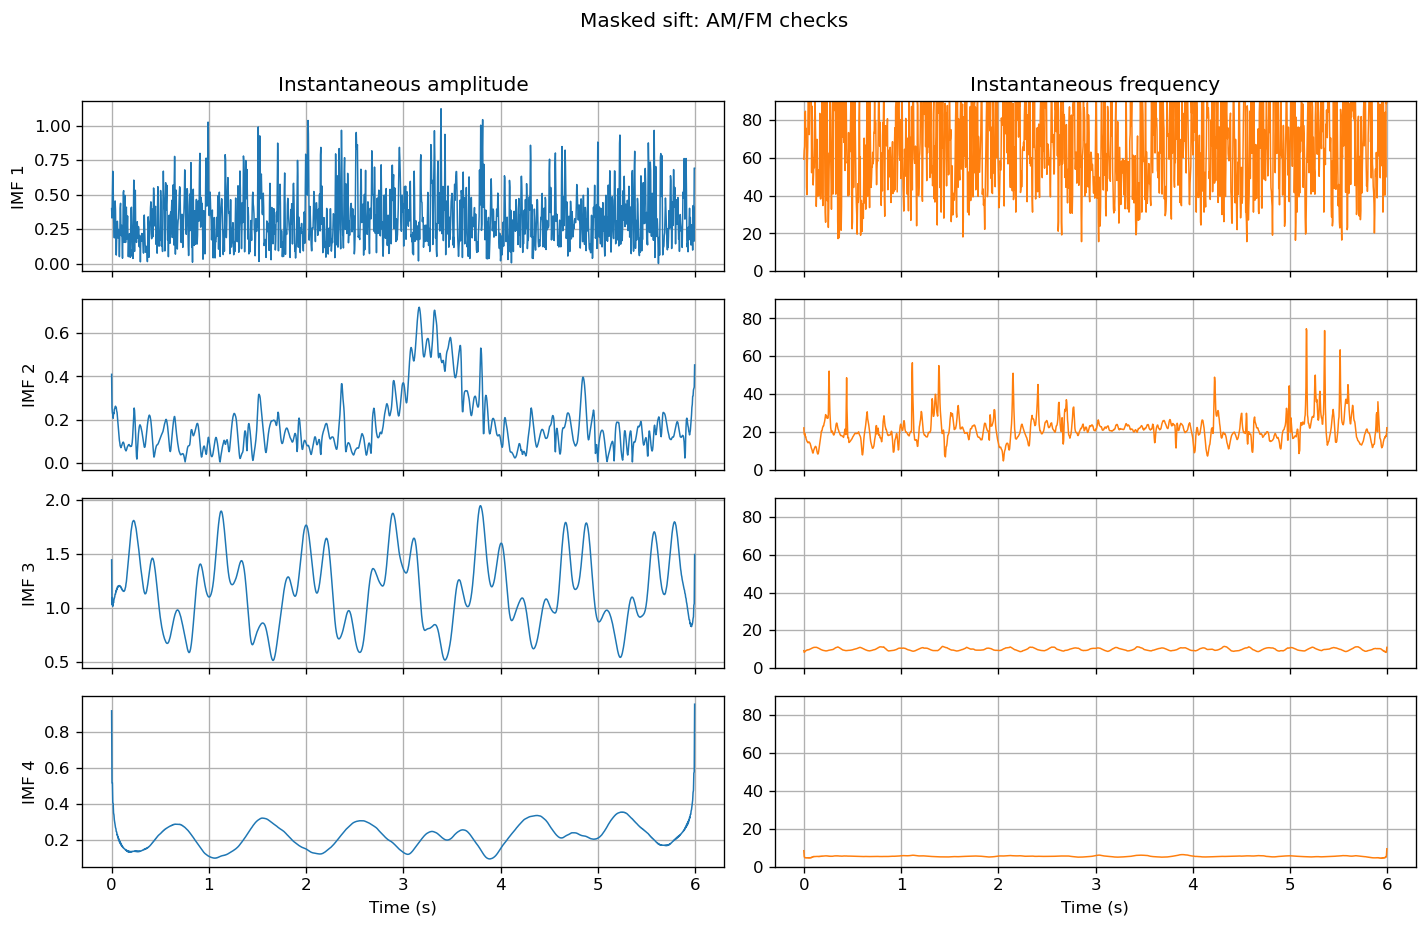

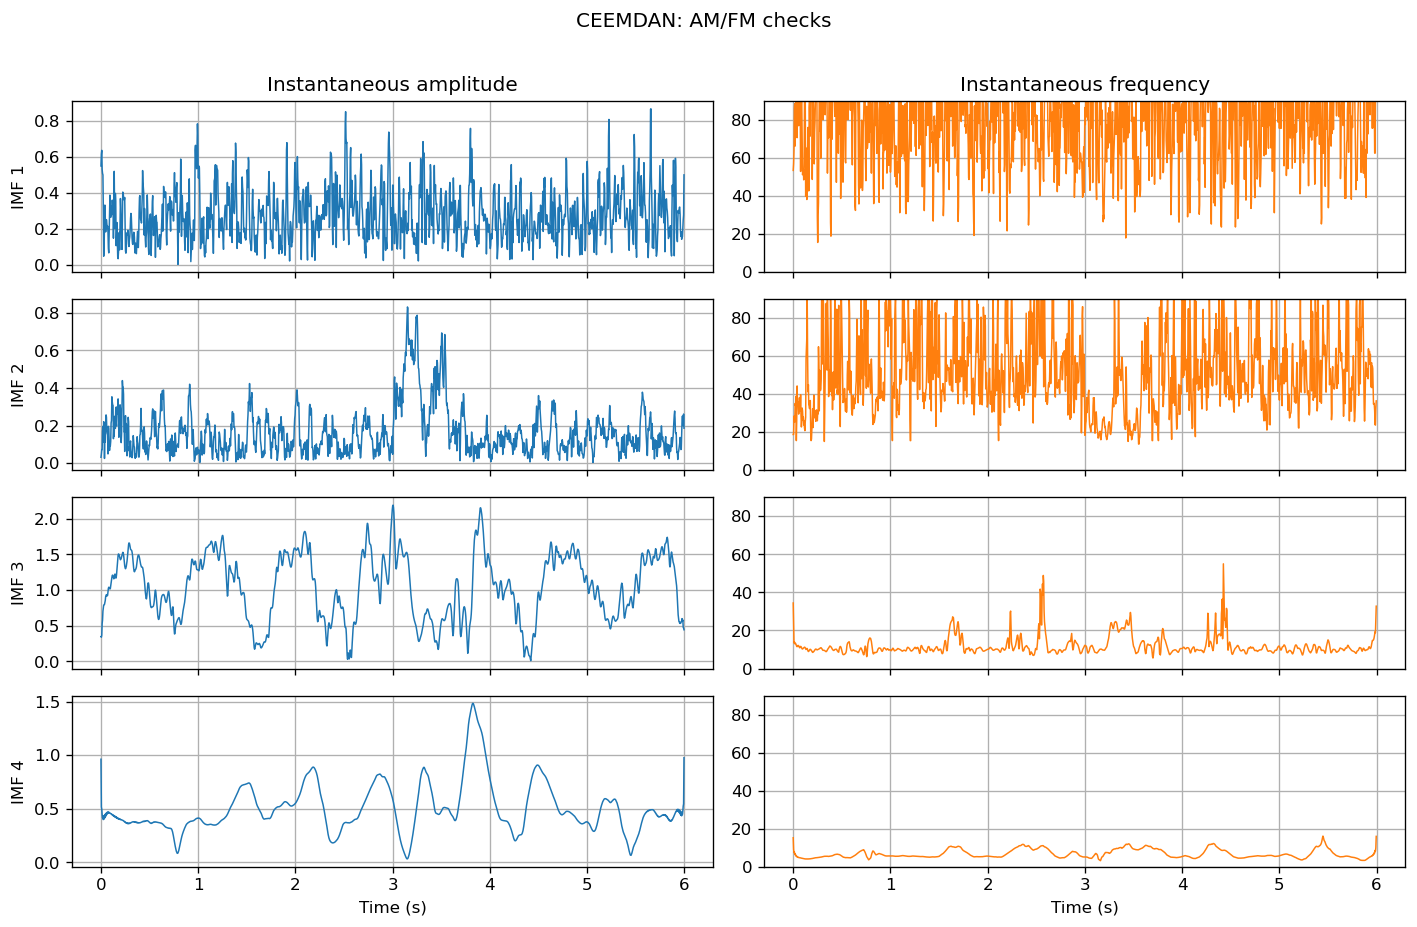

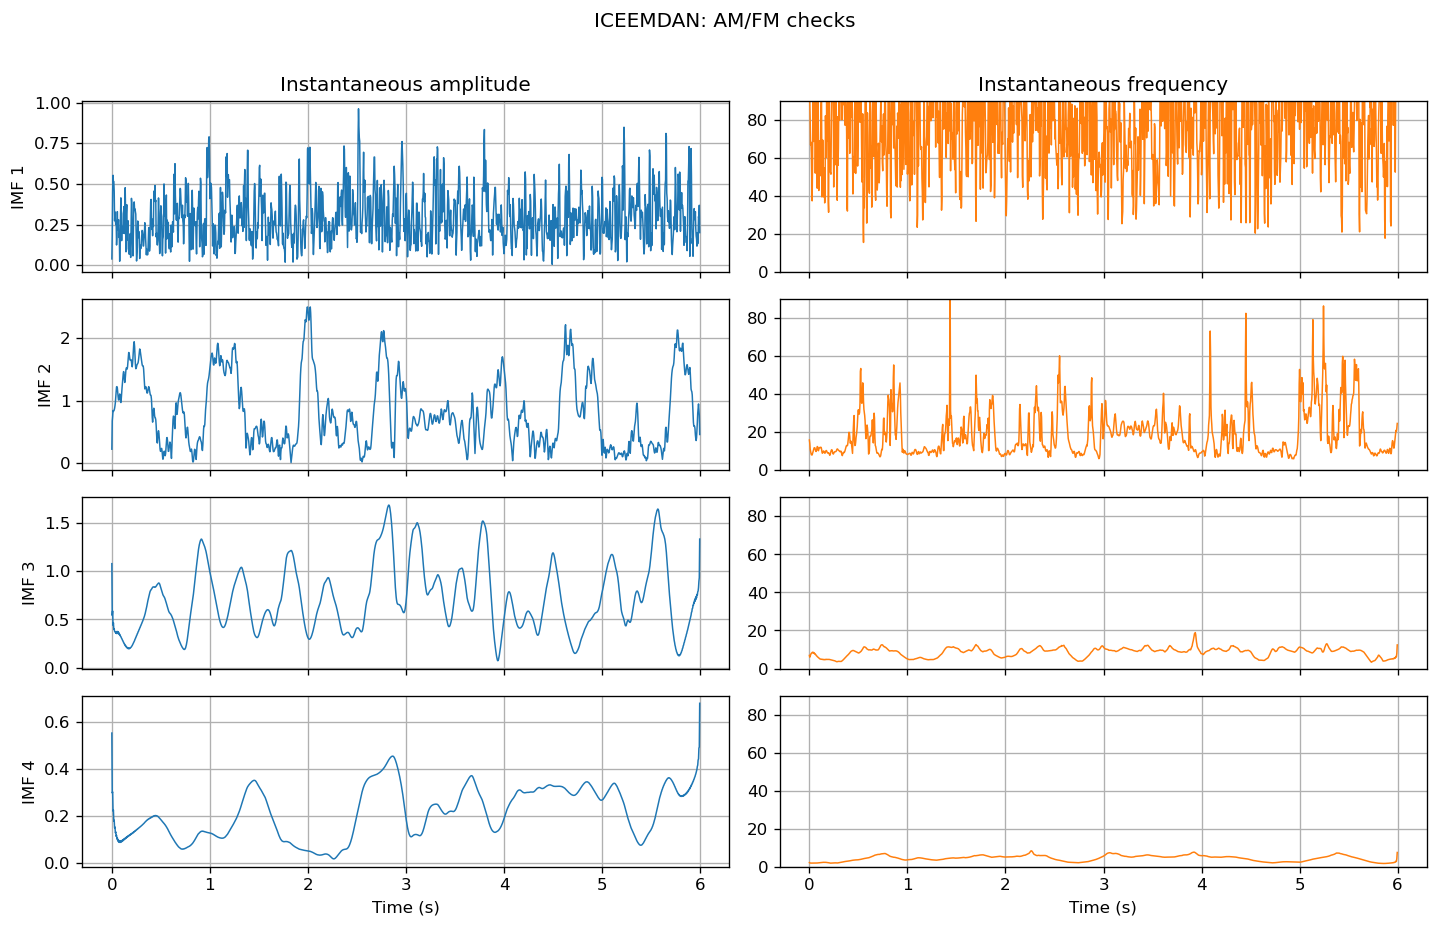

In [9]:
for label, result in results.items():
    plot_am_fm_diagnostics(result, label, max_modes=COMMON_KWARGS["max_imfs"], max_frequency=90.0);


## 8. Second-Layer Amplitude-Modulation Checks

HHSA decomposes each carrier IMF's amplitude envelope. This cell chooses the strongest carrier IMF by energy and displays the envelope decomposition plus its AM-frequency tracks.


Ensemble sift: showing second-layer decomposition for carrier IMF 2
Masked sift: showing second-layer decomposition for carrier IMF 3
CEEMDAN: showing second-layer decomposition for carrier IMF 3
ICEEMDAN: showing second-layer decomposition for carrier IMF 2


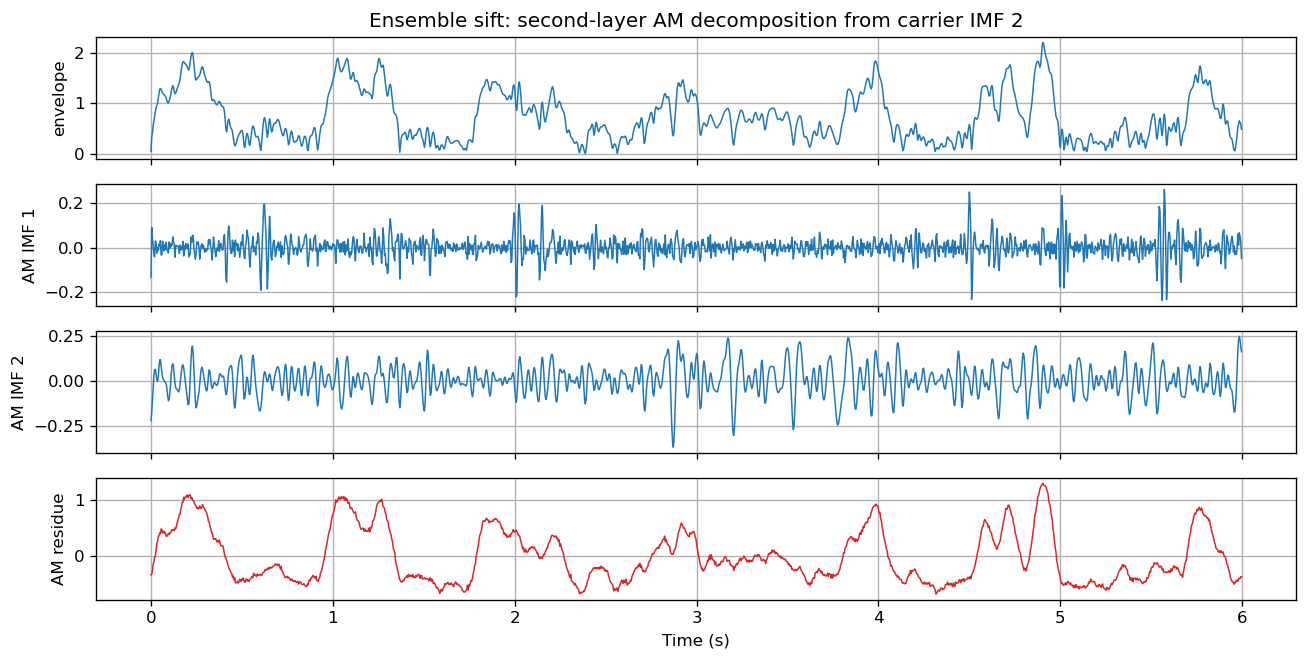

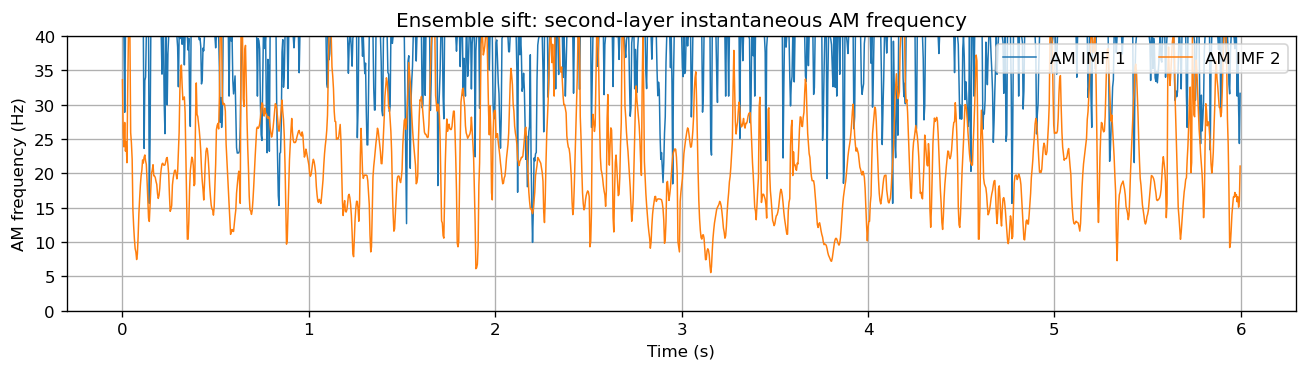

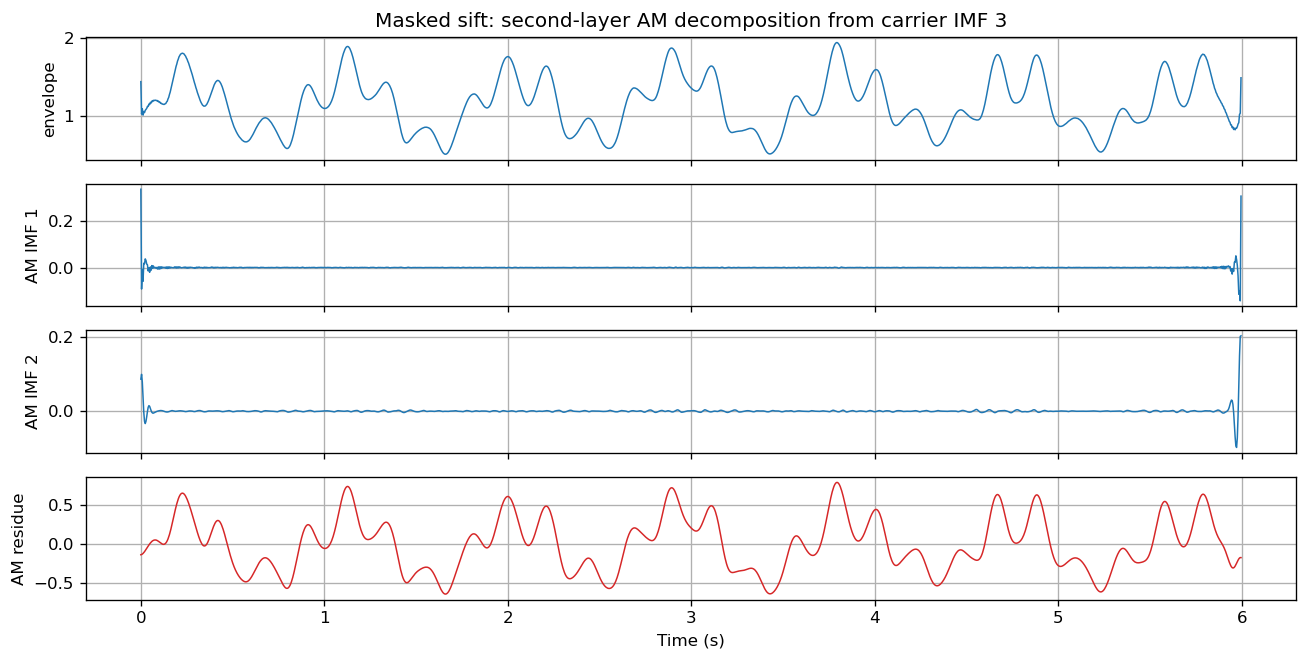

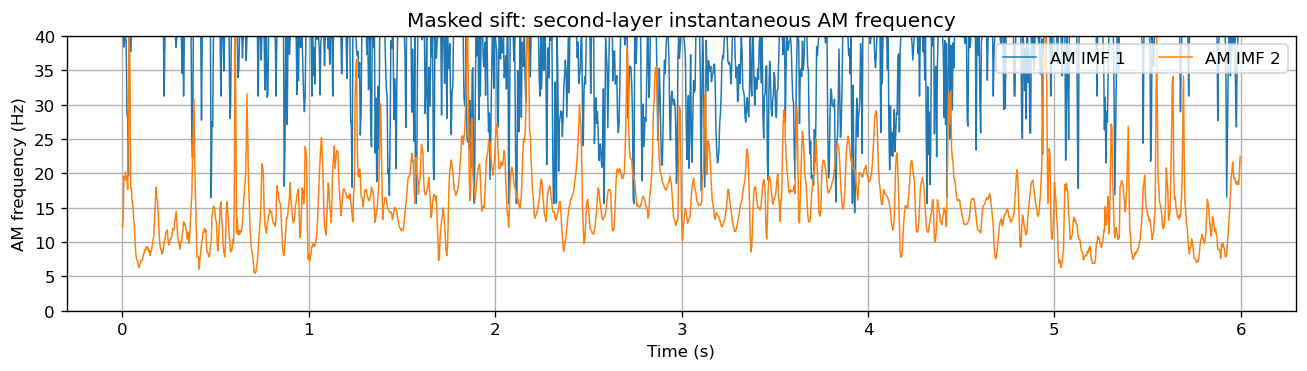

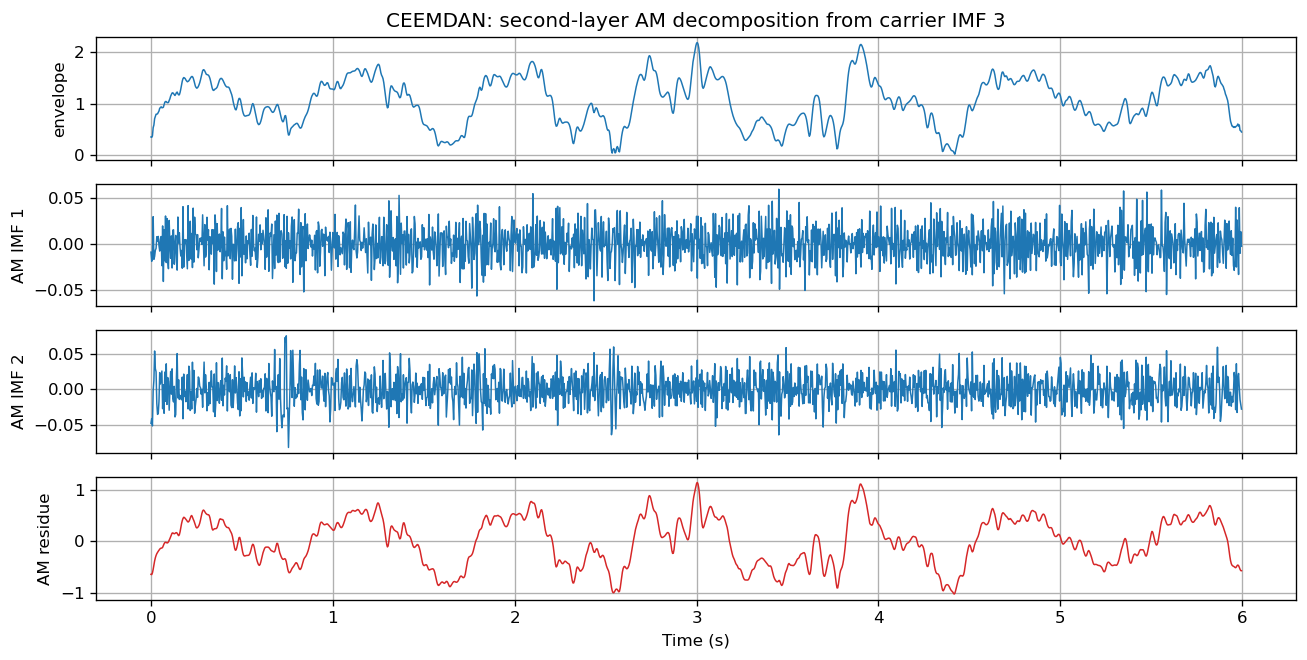

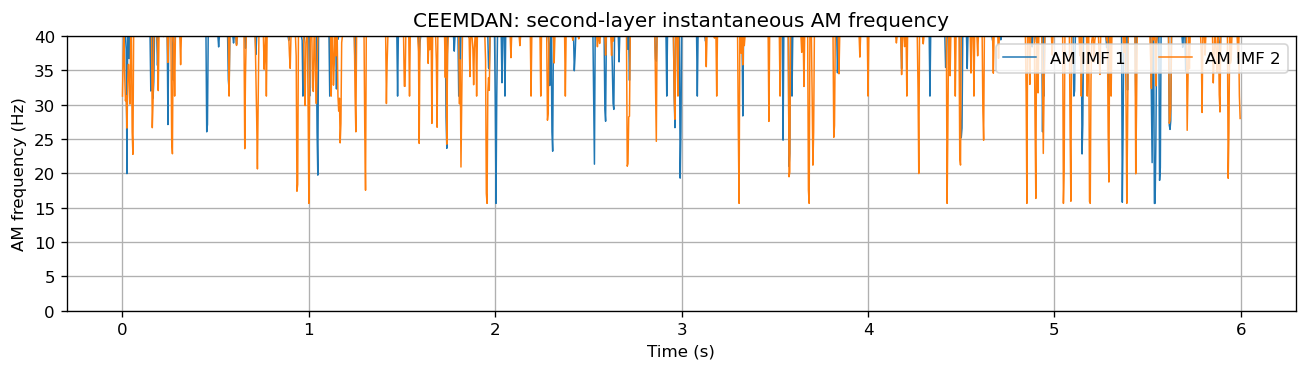

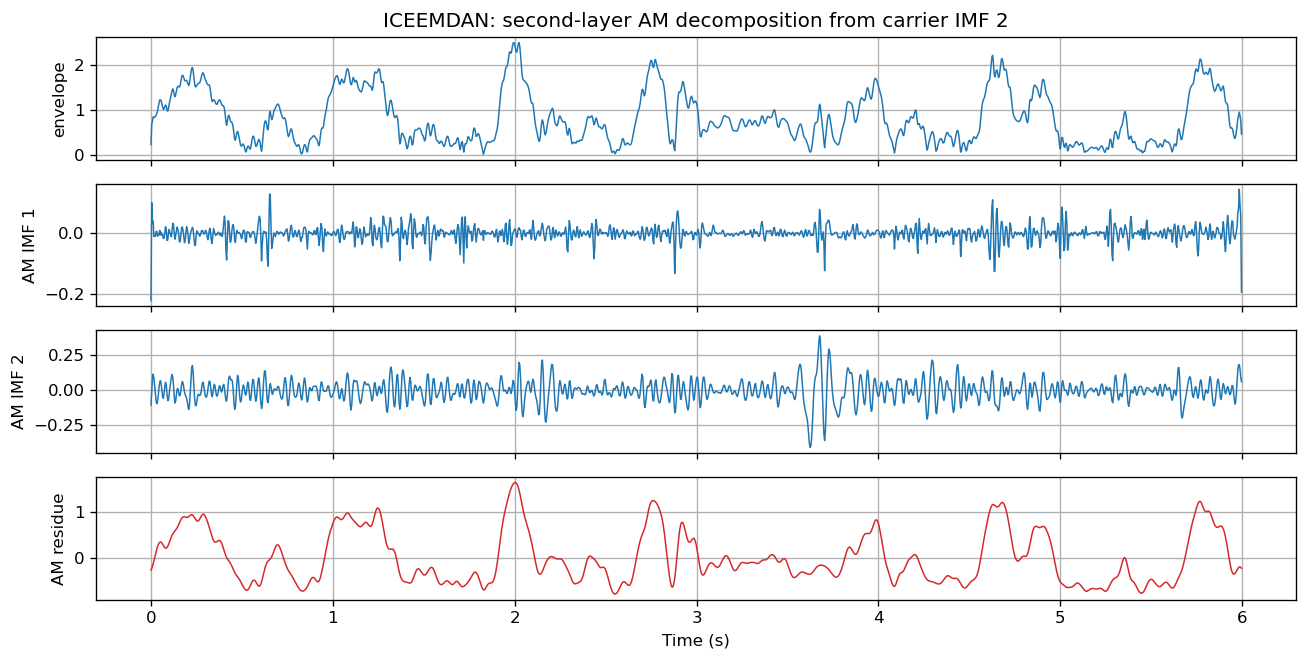

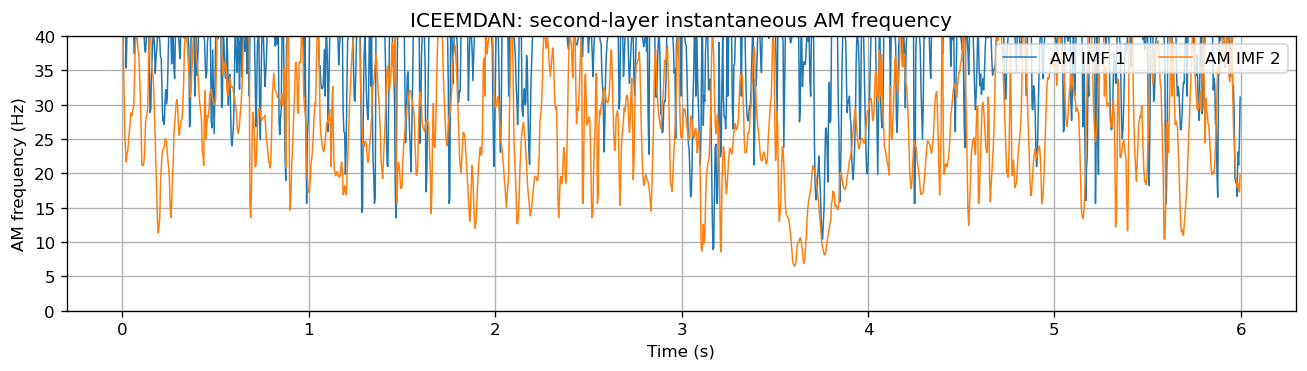

In [10]:
for label, result in results.items():
    carrier_index = strongest_imf_index(result)
    print(f"{label}: showing second-layer decomposition for carrier IMF {carrier_index + 1 if carrier_index is not None else 'none'}")
    plot_second_layer_diagnostics(result, label, carrier_index=carrier_index, max_am_modes=COMMON_KWARGS["max_am_imfs"], max_frequency=40.0);


## 9. Hilbert-Huang and Holo-Hilbert Spectral Checks

The marginal HHT shows the carrier-frequency distribution. The HHT image should localize carrier activity over time, and the holospectrum should show which amplitude-modulation frequencies are associated with each carrier band.


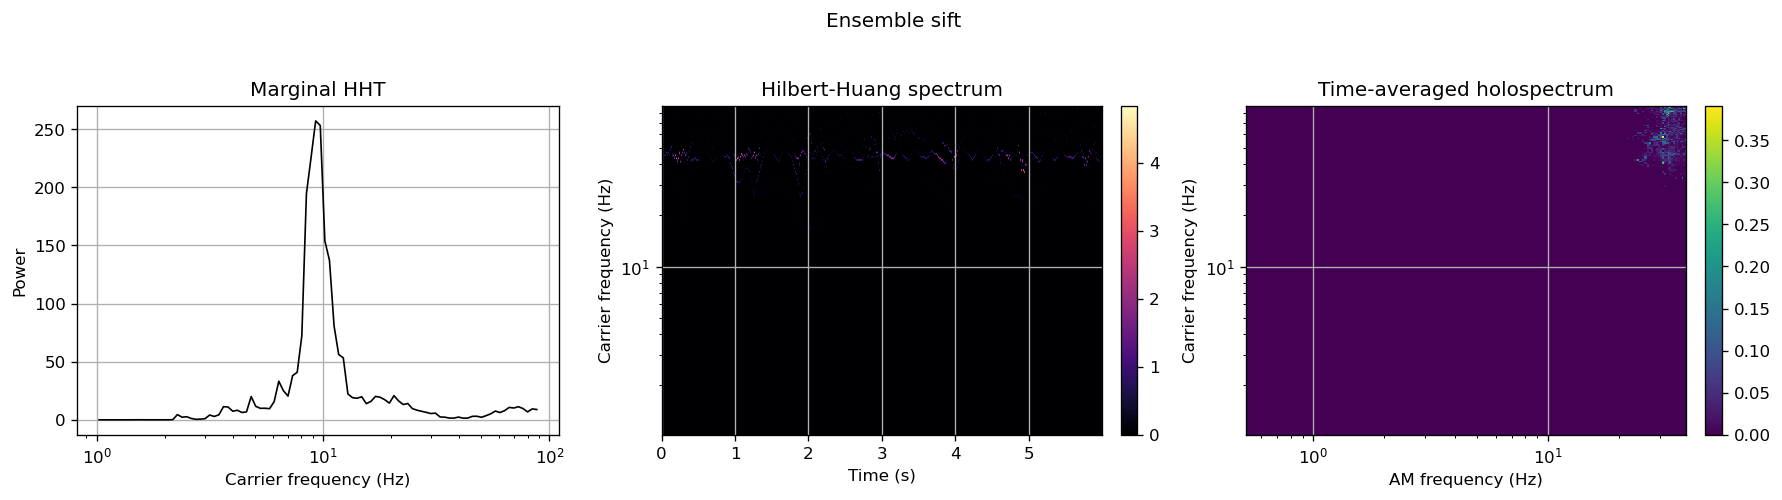

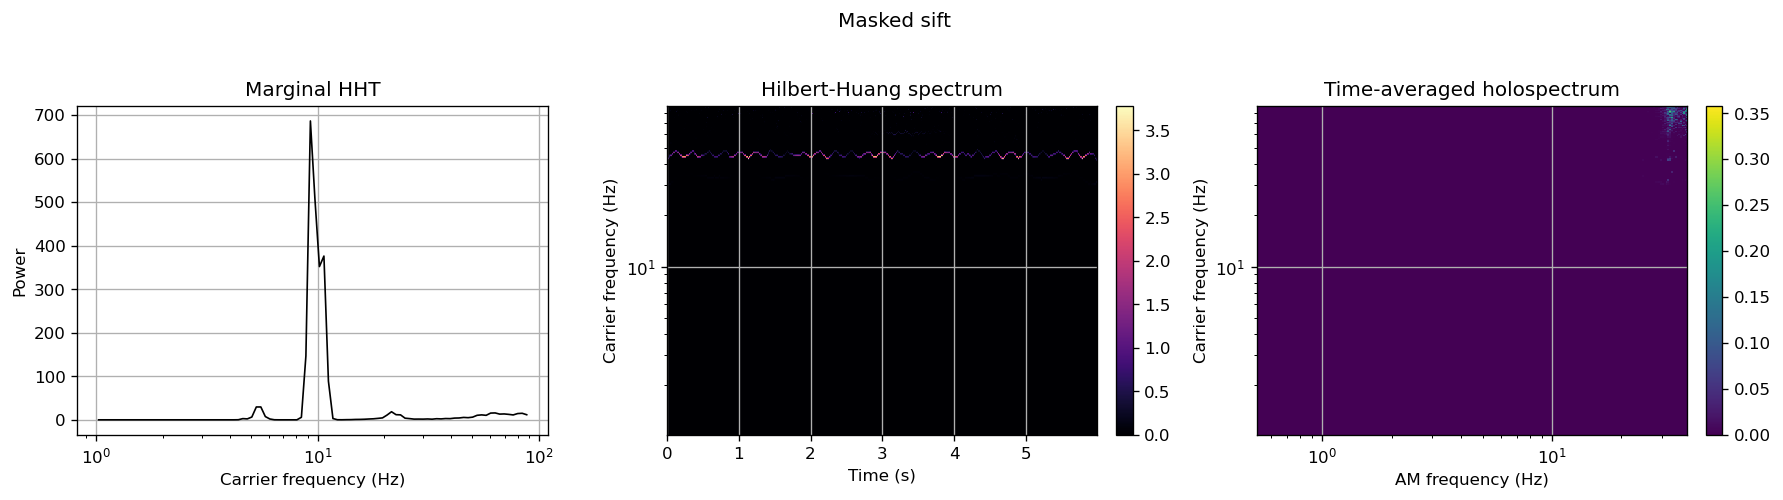

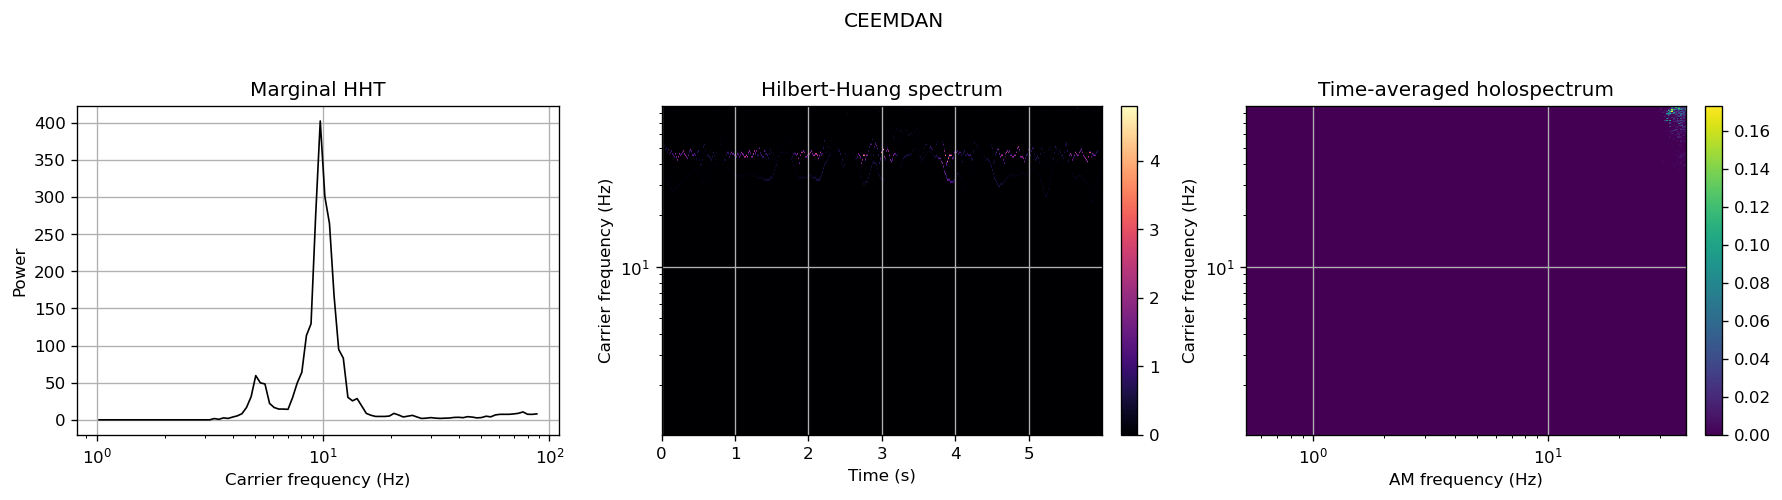

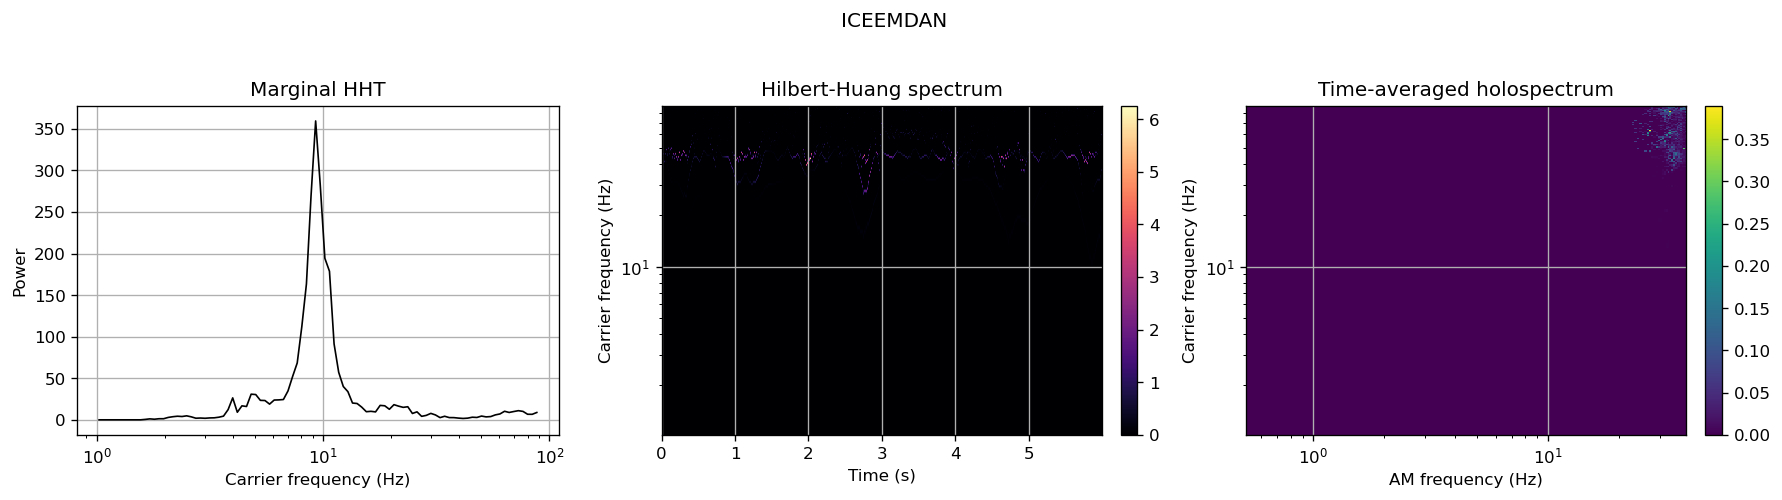

In [11]:
for label, result in results.items():
    plot_spectral_diagnostics(result, label);


## 10. Compare Methods Quantitatively

This summary gives a quick numerical check across methods: reconstruction error, IMF count, dominant marginal carrier frequency, and normalized IMF energy. Use it to spot methods that extracted too few modes, over-split a component, or moved most energy into the residue.


Ensemble sift  | IMFs= 4 | recon=5.761e-18 | dominant HHT=  9.27 Hz
Masked sift    | IMFs= 4 | recon=4.623e-18 | dominant HHT=  9.27 Hz
CEEMDAN        | IMFs= 4 | recon=7.315e-18 | dominant HHT=  9.71 Hz
ICEEMDAN       | IMFs= 4 | recon=1.130e-16 | dominant HHT=  9.27 Hz


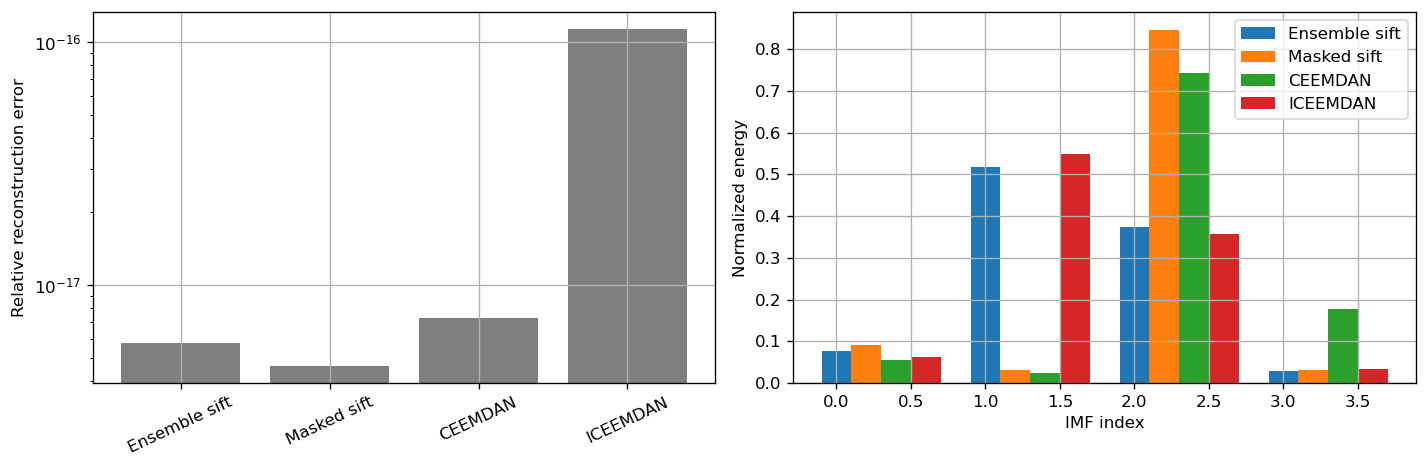

In [12]:
summary_rows = []
for label, result in results.items():
    dominant_idx = int(np.argmax(result.marginal)) if result.marginal.size else -1
    dominant_freq = result.carrier_bins[dominant_idx] if dominant_idx >= 0 else np.nan
    energies = mode_energy(result.imfs)
    summary_rows.append((label, result.imfs.shape[0], result.reconstruction_error, dominant_freq, energies))

for label, n_imfs, recon_error, dominant_freq, energies in summary_rows:
    print(f"{label:14s} | IMFs={n_imfs:2d} | recon={recon_error:.3e} | dominant HHT={dominant_freq:6.2f} Hz")

if summary_rows:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    labels = [row[0] for row in summary_rows]
    recon = [row[2] for row in summary_rows]
    axes[0].bar(labels, recon, color="tab:gray")
    axes[0].set_yscale("log")
    axes[0].set_ylabel("Relative reconstruction error")
    axes[0].tick_params(axis="x", rotation=25)

    width = 0.8 / max(1, len(summary_rows))
    for offset, (label, _, _, _, energies) in enumerate(summary_rows):
        if energies.size == 0:
            continue
        norm_energy = energies / (np.sum(energies) + np.finfo(float).eps)
        x = np.arange(norm_energy.size) + offset * width
        axes[1].bar(x, norm_energy, width=width, label=label)
    axes[1].set_xlabel("IMF index")
    axes[1].set_ylabel("Normalized energy")
    axes[1].legend(loc="upper right")
    fig.tight_layout()


## 11. Direct First-Layer Calls

If you only need decomposition arrays instead of the full HHSA result, call the lower-level functions directly. This is useful when you want to plug the IMFs into your own statistics or plotting code.


In [13]:
from hhsa import ceemdan, ensemble_sift, iceemdan, mask_sift

DIRECT_CALLS = {
    "ensemble_sift": (
        ensemble_sift,
        dict(max_imfs=4, ensemble_size=8, noise_width=0.12, random_state=42),
    ),
    "mask_sift": (
        mask_sift,
        dict(
            max_imfs=4,
            mask_freqs=np.array([45.0, 25.0, 12.0, 6.0]) / sample_rate,
            mask_amp=1.0,
            mask_amp_mode="ratio_sig",
        ),
    ),
    "ceemdan": (
        ceemdan,
        dict(max_imfs=4, ensemble_size=8, noise_width=0.12, random_state=42),
    ),
    "iceemdan": (
        iceemdan,
        dict(max_imfs=4, ensemble_size=8, noise_width=0.12, random_state=42),
    ),
}

print("Direct first-layer decomposition calls:")
for name, (function, kwargs) in DIRECT_CALLS.items():
    try:
        imfs, residue = function(signal, **kwargs)
        recon_error = np.linalg.norm(signal - (imfs.sum(axis=0) + residue)) / (np.linalg.norm(signal) + np.finfo(float).eps)
        print(f"  {name:14s}: imfs={imfs.shape}, residue={residue.shape}, recon={recon_error:.3e}")
    except Exception as exc:
        print(f"  {name:14s}: skipped ({type(exc).__name__}: {exc})")


Direct first-layer decomposition calls:
  ensemble_sift : imfs=(4, 1500), residue=(1500,), recon=5.761e-18
  mask_sift     : imfs=(4, 1500), residue=(1500,), recon=4.623e-18
  ceemdan       : imfs=(4, 1500), residue=(1500,), recon=7.704e-18
  iceemdan      : imfs=(4, 1500), residue=(1500,), recon=1.130e-16


## Practical Notes

- Start with one clean channel and a short segment before running full MEG arrays.
- Increase `ensemble_size` to 50-200 for final CEEMDAN/ICEEMDAN analyses after the workflow is validated.
- For `mask_sift`, tune `mask_freqs` to the bands expected in your data; values here target common MEG theta/alpha/beta/gamma-like activity.
- If CEEMDAN or ICEEMDAN are slow, try `sift_acceleration="cpu"` and `n_jobs=-1` in `COMMON_KWARGS`.
- Interpret edge samples cautiously; spline-envelope methods commonly show endpoint artifacts.
